In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
from misophonia_dataset.interface import get_data_dir
from misophonia_dataset._binamix import setup_binamix
from misophonia_dataset._log import setup_print_logging
from misophonia_dataset.interface import SourceData, get_data_dir
from misophonia_dataset.misophonia_dataset import (
    GeneratedMisophoniaDataset,
    PremadeMisophoniaDataset,
    add_experimental_pairs_to_dataset,
)
from misophonia_dataset.source_data.esc50 import Esc50Dataset
from misophonia_dataset.source_data.foams import FoamsDataset
from misophonia_dataset.source_data.fsd50k import Fsd50kDataset
from misophonia_dataset.main import get_dataset_from_name

setup_print_logging()

from misophonia_dataset._analysis import models_to_df
from misophonia_dataset.interface import (
    GlobalMixingParams,
    MisophoniaDataset,
    MisophoniaDatasetSplit,
    MisophoniaItem,
    SourceData,
    SourceDataItem,
    SplitT,
    get_data_dir,
    DEFAULT_LABEL_ORDER,
)

import itertools
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Mapping, Sequence
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import rankdata
from tqdm import tqdm

from pathlib import Path
from matplotlib.transforms import blended_transform_factory

[2026-05-29 10:57:28] [DEBUG] Set up print logging


In [3]:
results_json = get_data_dir() / "model-aux-ft-all-gt-clean-mix" / "eval_results/" / "ema_best_by_ema_test_results.json"
assert results_json.exists(), f"Expected results json at {results_json}"

In [4]:
source_data = tuple(get_dataset_from_name(name) for name in ("foams", "esc50", "fsd50k"))

all_source_data = tuple(itertools.chain.from_iterable(ds.get_metadata() for ds in source_data))

items_by_split: dict[SplitT, list[SourceDataItem]] = {"train": [], "val": [], "test": []}

for item in all_source_data:
    items_by_split[item.split].append(item)


target_items = {cat: [] for cat in DEFAULT_LABEL_ORDER}

for item in items_by_split["test"]:
    if len(item.labels) == 1:
        cat = item.labels[0]
        if cat in target_items:
            target_items[cat].append(item)

In [5]:
preprocessed = []

sr = 44100

for cat, items in target_items.items():
    for item in tqdm(items, desc=f"Preprocessing category '{cat}'"):
        audio, _ = item.load_audio(sample_rate=sr)
        preprocessed.append((item.labels[0], item.freesound_id, audio))

print(f"Total preprocessed items: {len(preprocessed)}")

Preprocessing category 'water_drops': 100%|██████████| 63/63 [00:00<00:00, 122.80it/s]

Total preprocessed items: 515


In [6]:
@dataclass(frozen=True)
class EventFeatureConfig:
    frame_ms: float = 20.0
    hop_ms: float = 10.0
    trim_top_db: float = 60.0
    active_top_db: float = 25.0
    min_region_ms: float = 30.0
    merge_gap_ms: float = 50.0
    attack_low_frac: float = 0.20
    attack_high_frac: float = 0.90

    spectral_n_fft: int = 2048
    spectral_roll_percent: float = 0.85
    spectral_contrast_fmin: float = 200.0
    spectral_contrast_n_bands: int = 6
    spectral_contrast_quantile: float = 0.02

    eps: float = 1e-10


@dataclass(frozen=True)
class FeatureBootstrapResult:
    source_features: pd.DataFrame
    mixture_results: pd.DataFrame
    source_table: pd.DataFrame
    excluded_mixtures: pd.DataFrame
    excluded_source_ids: pd.DataFrame
    observed_correlations: pd.DataFrame
    bootstrap_summary: pd.DataFrame
    boot_correlations: pd.DataFrame


def normalize_id(x: Any) -> str:
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    return str(x)


def canonical_category(category: str, aliases: Mapping[str, str] | None) -> str:
    return aliases.get(category, category) if aliases is not None else category


def ms_to_samples(ms: float, sr: int, minimum: int = 1) -> int:
    return max(minimum, int(round(ms * sr / 1000.0)))


def ms_to_frames(ms: float, sr: int, hop_length: int, minimum: int = 1) -> int:
    return max(minimum, int(round(ms * sr / (1000.0 * hop_length))))


def safe_median(values: Sequence[float]) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan


### Spectral
def finite_median_array(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan


def spectral_contrast_safe(
    S: np.ndarray,
    sr: int,
    fmin: float,
    n_bands: int,
    quantile: float,
) -> np.ndarray:
    current_n_bands = int(n_bands)

    while current_n_bands >= 1:
        try:
            return librosa.feature.spectral_contrast(
                S=S,
                sr=sr,
                fmin=fmin,
                n_bands=current_n_bands,
                quantile=quantile,
                linear=False,
            )
        except ValueError:
            current_n_bands -= 1

    return np.full((1, S.shape[1]), np.nan, dtype=float)


def extract_spectral_features(
    audio: np.ndarray,
    sr: int,
    cfg: EventFeatureConfig,
    hop_length: int,
) -> dict[str, float]:
    x = np.asarray(audio, dtype=np.float32).squeeze()

    out = {
        "spectral_centroid_hz": np.nan,
        "spectral_bandwidth_hz": np.nan,
        "spectral_rolloff_hz": np.nan,
        "spectral_flatness": np.nan,
        "spectral_contrast": np.nan,
    }

    if x.ndim != 1 or len(x) == 0 or np.max(np.abs(x)) <= cfg.eps:
        return out

    n_fft = int(cfg.spectral_n_fft)

    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    S = np.abs(
        librosa.stft(
            y=x,
            n_fft=n_fft,
            hop_length=hop_length,
            window="hann",
            center=True,
        )
    )

    if S.size == 0 or np.nanmax(S) <= cfg.eps:
        return out

    centroid = librosa.feature.spectral_centroid(
        S=S,
        sr=sr,
    )

    bandwidth = librosa.feature.spectral_bandwidth(
        S=S,
        sr=sr,
        centroid=centroid,
        p=2,
        norm=True,
    )

    rolloff = librosa.feature.spectral_rolloff(
        S=S,
        sr=sr,
        roll_percent=cfg.spectral_roll_percent,
    )

    flatness = librosa.feature.spectral_flatness(
        S=S,
        power=2.0,
        amin=cfg.eps,
    )

    contrast = spectral_contrast_safe(
        S=S,
        sr=sr,
        fmin=cfg.spectral_contrast_fmin,
        n_bands=cfg.spectral_contrast_n_bands,
        quantile=cfg.spectral_contrast_quantile,
    )

    out.update(
        {
            "spectral_centroid_hz": finite_median_array(centroid),
            "spectral_bandwidth_hz": finite_median_array(bandwidth),
            "spectral_rolloff_hz": finite_median_array(rolloff),
            "spectral_flatness": finite_median_array(flatness),
            "spectral_contrast": finite_median_array(contrast),
        }
    )

    return out


#### Temporal
def robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    med = x.median()
    iqr = x.quantile(0.75) - x.quantile(0.25)

    if np.isfinite(iqr) and iqr > 0:
        return (x - med) / iqr

    std = x.std()
    scale = std if np.isfinite(std) and std > 0 else 1.0
    return (x - med) / scale


def gini_nonnegative(x: np.ndarray, eps: float = 1e-10) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = np.maximum(x, 0.0)

    if len(x) == 0 or np.sum(x) <= eps:
        return np.nan

    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)

    return float(np.sum((2 * idx - n - 1) * x) / (n * np.sum(x) + eps))


def boolean_runs(mask: np.ndarray) -> np.ndarray:
    mask = np.asarray(mask, dtype=bool)

    if len(mask) == 0:
        return np.empty((0, 2), dtype=int)

    padded = np.r_[False, mask, False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])

    return changes.reshape(-1, 2).astype(int)


def merge_and_filter_regions(
    regions: np.ndarray,
    min_frames: int,
    merge_gap_frames: int,
) -> np.ndarray:
    if len(regions) == 0:
        return np.empty((0, 2), dtype=int)

    merged = [tuple(regions[0])]

    for start, end in regions[1:]:
        prev_start, prev_end = merged[-1]

        if start - prev_end <= merge_gap_frames:
            merged[-1] = (prev_start, int(end))
        else:
            merged.append((int(start), int(end)))

    merged = np.asarray(merged, dtype=int)
    keep = (merged[:, 1] - merged[:, 0]) >= min_frames

    return merged[keep]


def frame_regions_to_time(
    regions: np.ndarray,
    hop_length: int,
    sr: int,
    duration_s: float,
) -> tuple[np.ndarray, np.ndarray]:
    if len(regions) == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    starts = regions[:, 0] * hop_length / sr
    ends = regions[:, 1] * hop_length / sr
    starts = np.clip(starts, 0.0, duration_s)
    ends = np.clip(ends, 0.0, duration_s)

    keep = ends > starts

    return starts[keep], ends[keep]


def attack_decay_for_region(
    rms: np.ndarray,
    start: int,
    end: int,
    hop_s: float,
    low_frac: float,
    high_frac: float,
) -> tuple[float, float]:
    seg = np.asarray(rms[start:end], dtype=float)

    if len(seg) < 2 or not np.any(np.isfinite(seg)):
        return np.nan, np.nan

    peak_idx = int(np.nanargmax(seg))
    peak = float(seg[peak_idx])

    if not np.isfinite(peak) or peak <= 0:
        return np.nan, np.nan

    low = low_frac * peak
    high = high_frac * peak

    pre = seg[: peak_idx + 1]
    post = seg[peak_idx:]

    attack = np.nan
    low_pre = np.flatnonzero(pre >= low)
    high_pre = np.flatnonzero(pre >= high)

    if len(low_pre) and len(high_pre):
        attack = max(0.0, float((high_pre[0] - low_pre[0]) * hop_s))

    decay = np.nan
    high_post = np.flatnonzero(post <= high)
    low_post = np.flatnonzero(post <= low)

    if len(high_post) and len(low_post):
        decay = max(0.0, float((low_post[0] - high_post[0]) * hop_s))

    return attack, decay


def local_prominence_db(
    rms_db: np.ndarray,
    active_mask: np.ndarray,
    min_distance_frames: int,
) -> float:
    if len(rms_db) < 3 or not np.any(np.isfinite(rms_db)):
        return np.nan

    finite = rms_db[np.isfinite(rms_db)]

    if len(finite) == 0:
        return np.nan

    x = np.nan_to_num(rms_db, nan=float(np.min(finite)))

    peaks, props = find_peaks(
        x,
        distance=max(1, min_distance_frames),
        prominence=(None, None),
    )

    if len(peaks) == 0:
        return np.nan

    active_peaks = active_mask[peaks]
    prominences = props["prominences"][active_peaks]

    return float(np.median(prominences)) if len(prominences) else np.nan


def extract_source_features(
    category: str,
    fg_freesound_id: Any,
    audio: np.ndarray,
    sr: int,
    cfg: EventFeatureConfig,
    aliases: Mapping[str, str] | None = None,
) -> dict[str, Any]:
    x = np.asarray(audio, dtype=np.float32).squeeze()

    if x.ndim != 1:
        raise ValueError("This feature extractor assumes mono audio.")

    x = np.nan_to_num(x)

    out = {
        "category": canonical_category(str(category), aliases),
        "fg_freesound_id": normalize_id(fg_freesound_id),
        "duration_s": np.nan,
        "n_active_regions": 0,
        "active_region_rate_per_s": np.nan,
        "active_fraction": np.nan,
        "median_active_region_duration_s": np.nan,
        "median_gap_duration_s": np.nan,
        "gap_to_active_ratio": np.nan,
        "median_attack_time_s": np.nan,
        "median_decay_time_s": np.nan,
        "median_onset_strength": np.nan,
        "median_local_prominence_db": np.nan,
        "envelope_gini": np.nan,
        "spectral_centroid_hz": np.nan,
        "spectral_bandwidth_hz": np.nan,
        "spectral_rolloff_hz": np.nan,
        "spectral_flatness": np.nan,
        "spectral_contrast": np.nan,
    }

    if len(x) == 0 or np.max(np.abs(x)) <= cfg.eps:
        return out

    frame_length = ms_to_samples(cfg.frame_ms, sr)
    hop_length = ms_to_samples(cfg.hop_ms, sr)
    hop_s = hop_length / sr

    x, _ = librosa.effects.trim(
        x,
        top_db=cfg.trim_top_db,
        frame_length=frame_length,
        hop_length=hop_length,
    )

    if len(x) == 0 or np.max(np.abs(x)) <= cfg.eps:
        return out

    scale = np.percentile(np.abs(x), 95)

    if np.isfinite(scale) and scale > cfg.eps:
        x = (x / scale).astype(np.float32)

    duration_s = len(x) / sr

    rms = librosa.feature.rms(
        y=x,
        frame_length=frame_length,
        hop_length=hop_length,
        center=True,
    )[0].astype(float)

    if len(rms) == 0 or np.nanmax(rms) <= cfg.eps:
        return out

    rms_db = librosa.amplitude_to_db(rms, ref=np.nanmax, top_db=None)
    active_mask = rms_db >= -cfg.active_top_db

    min_region_frames = ms_to_frames(cfg.min_region_ms, sr, hop_length)
    merge_gap_frames = ms_to_frames(cfg.merge_gap_ms, sr, hop_length, minimum=0)

    frame_regions = merge_and_filter_regions(
        boolean_runs(active_mask),
        min_frames=min_region_frames,
        merge_gap_frames=merge_gap_frames,
    )

    starts, ends = frame_regions_to_time(frame_regions, hop_length, sr, duration_s)

    region_durations = ends - starts
    gaps = starts[1:] - ends[:-1] if len(starts) >= 2 else np.array([], dtype=float)

    onset_env = librosa.onset.onset_strength(
        y=x,
        sr=sr,
        hop_length=hop_length,
        aggregate=np.mean,
        n_fft=frame_length,
    ).astype(float)

    attacks, decays, onset_strengths = [], [], []

    for start_frame, end_frame in frame_regions:
        start_frame = max(0, int(start_frame))
        end_frame = min(len(rms), int(end_frame))

        if end_frame <= start_frame:
            continue

        attack, decay = attack_decay_for_region(
            rms=rms,
            start=start_frame,
            end=end_frame,
            hop_s=hop_s,
            low_frac=cfg.attack_low_frac,
            high_frac=cfg.attack_high_frac,
        )

        attacks.append(attack)
        decays.append(decay)

        onset_start = min(start_frame, len(onset_env))
        onset_end = min(end_frame, len(onset_env))
        onset_seg = onset_env[onset_start:onset_end]

        if len(onset_seg):
            onset_strengths.append(float(np.nanmax(onset_seg)))

    med_region = safe_median(region_durations)
    med_gap = safe_median(gaps)

    out.update(
        {
            "duration_s": float(duration_s),
            "n_active_regions": int(len(region_durations)),
            "active_region_rate_per_s": float(len(region_durations) / duration_s) if duration_s > 0 else np.nan,
            "active_fraction": float(min(1.0, np.nansum(region_durations) / duration_s)) if duration_s > 0 else np.nan,
            "median_active_region_duration_s": med_region,
            "median_gap_duration_s": med_gap,
            "gap_to_active_ratio": float(med_gap / med_region) if np.isfinite(med_gap) and med_region > 0 else np.nan,
            "median_attack_time_s": safe_median(attacks),
            "median_decay_time_s": safe_median(decays),
            "median_onset_strength": safe_median(onset_strengths),
            "median_local_prominence_db": local_prominence_db(
                rms_db=rms_db,
                active_mask=active_mask,
                min_distance_frames=min_region_frames,
            ),
            "envelope_gini": gini_nonnegative(rms, cfg.eps),
            **extract_spectral_features(
                audio=x,
                sr=sr,
                cfg=cfg,
                hop_length=hop_length,
            ),
        }
    )

    return out


def precompute_source_features(
    preprocessed: Sequence[tuple[str, Any, np.ndarray]],
    sr: int,
    cfg: EventFeatureConfig,
    aliases: Mapping[str, str] | None = None,
) -> pd.DataFrame:
    rows = [
        extract_source_features(
            category=category,
            fg_freesound_id=fg_freesound_id,
            audio=audio,
            sr=sr,
            cfg=cfg,
            aliases=aliases,
        )
        for category, fg_freesound_id, audio in tqdm(
            preprocessed,
            desc="Precomputing source features",
        )
    ]

    features = pd.DataFrame(rows)

    base_feature_cols = [
        # Temporal
        "active_fraction",
        "median_active_region_duration_s",
        "median_gap_duration_s",
        "gap_to_active_ratio",
        "median_attack_time_s",
        "median_decay_time_s",
        "median_onset_strength",
        "median_local_prominence_db",
        "envelope_gini",
        "active_region_rate_per_s",
        # Spectral
        "spectral_centroid_hz",
        "spectral_bandwidth_hz",
        "spectral_rolloff_hz",
        "spectral_flatness",
        "spectral_contrast",
    ]

    for col in base_feature_cols:
        features[f"{col}_z"] = robust_z(features[col])

    features["salience_sparsity_score"] = features[["median_local_prominence_db_z", "envelope_gini_z"]].mean(
        axis=1, skipna=True
    )

    features["intermittency_score"] = pd.concat(
        [
            -features["active_fraction_z"],
            -features["median_active_region_duration_s_z"],
            features["gap_to_active_ratio_z"],
        ],
        axis=1,
    ).mean(axis=1, skipna=True)

    features["boundary_sharpness_score"] = pd.concat(
        [
            -features["median_attack_time_s_z"],
            -features["median_decay_time_s_z"],
            features["median_onset_strength_z"],
        ],
        axis=1,
    ).mean(axis=1, skipna=True)

    features["broad_event_structure_score"] = features[
        [
            "salience_sparsity_score",
            "intermittency_score",
            "boundary_sharpness_score",
        ]
    ].mean(axis=1, skipna=True)

    return features.groupby(["fg_freesound_id", "category"], as_index=False).median(numeric_only=True)


def load_mixture_results(
    results_json: Path,
    metric_name: str,
    aliases: Mapping[str, str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    with open(results_json, "r", encoding="utf-8") as f:
        data = json.load(f)

    candidate_rows = []
    excluded_rows = []
    excluded_source_ids: set[str] = set()

    for item in data:
        metadata = item.get("sample_metadata", {})
        metrics = item.get("metrics", {})

        raw_fg_ids = metadata.get("fg_freesound_ids", [])
        raw_fg_categories = metadata.get("fg_categories", [])

        fg_ids = tuple(normalize_id(x) for x in raw_fg_ids)
        fg_categories = tuple(canonical_category(str(x), aliases) for x in raw_fg_categories)

        eval_idx = item.get("idx")

        if len(fg_ids) != 1:
            excluded_rows.append(
                {
                    "eval_idx": eval_idx,
                    "fg_freesound_ids": fg_ids,
                    "fg_categories": fg_categories,
                    "reason": "not_exactly_one_foreground_id",
                }
            )

            for fg_id in fg_ids:
                excluded_source_ids.add(fg_id)

            continue

        fg_id = fg_ids[0]

        if len(fg_categories) != 1:
            excluded_source_ids.add(fg_id)

            excluded_rows.append(
                {
                    "eval_idx": eval_idx,
                    "fg_freesound_ids": fg_ids,
                    "fg_categories": fg_categories,
                    "reason": "not_exactly_one_foreground_category",
                }
            )

            continue

        candidate_rows.append(
            {
                "eval_idx": eval_idx,
                "fg_freesound_id": fg_id,
                "category": fg_categories[0],
                "bg_freesound_ids": tuple(normalize_id(x) for x in metadata.get("bg_freesound_ids", [])),
                "bg_categories": tuple(canonical_category(str(x), aliases) for x in metadata.get("bg_categories", [])),
                metric_name: metrics.get(metric_name),
            }
        )

    mixture_results = pd.DataFrame(candidate_rows)

    if len(mixture_results):
        mixture_results[metric_name] = pd.to_numeric(
            mixture_results[metric_name],
            errors="coerce",
        )

        mixture_results = (
            mixture_results.loc[~mixture_results["fg_freesound_id"].isin(excluded_source_ids)]
            .dropna(subset=[metric_name])
            .reset_index(drop=True)
        )

    excluded_mixtures = pd.DataFrame(excluded_rows)

    excluded_source_ids_df = pd.DataFrame(
        {
            "fg_freesound_id": sorted(excluded_source_ids),
        }
    )

    return mixture_results, excluded_mixtures, excluded_source_ids_df


def make_source_table(
    mixture_results: pd.DataFrame,
    source_features: pd.DataFrame,
    metric_name: str,
) -> pd.DataFrame:
    joined = mixture_results.merge(
        source_features,
        on=["fg_freesound_id", "category"],
        how="inner",
        validate="many_to_one",
    )

    performance = joined.groupby(["fg_freesound_id", "category"], as_index=False).agg(
        n_mixtures=("eval_idx", "count"),
        metric_mean=(metric_name, "mean"),
        metric_std=(metric_name, "std"),
    )

    feature_cols = [col for col in source_features.columns if col not in {"fg_freesound_id", "category"}]

    return performance.merge(
        source_features[["fg_freesound_id", "category", *feature_cols]],
        on=["fg_freesound_id", "category"],
        how="inner",
        validate="one_to_one",
    )


def bootstrap_feature_columns() -> list[str]:
    return [
        "broad_event_structure_score",
        "boundary_sharpness_score",
        "intermittency_score",
        "salience_sparsity_score",
        "active_fraction_z",
        "median_active_region_duration_s_z",
        "median_gap_duration_s_z",
        "gap_to_active_ratio_z",
        "median_attack_time_s_z",
        "median_decay_time_s_z",
        "median_onset_strength_z",
        "median_local_prominence_db_z",
        "envelope_gini_z",
        "spectral_centroid_hz_z",
        "spectral_bandwidth_hz_z",
        "spectral_rolloff_hz_z",
        "spectral_flatness_z",
        "spectral_contrast_z",
    ]


def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan

    return float(np.corrcoef(rankdata(x), rankdata(y))[0, 1])


def spearman_all_features(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.asarray(
        [spearman_rho(X[:, j], y) for j in range(X.shape[1])],
        dtype=float,
    )


def center_within_category(
    X: np.ndarray,
    y: np.ndarray,
    categories: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    Xc = X.copy()
    yc = y.copy()

    for category in np.unique(categories):
        idx = np.where(categories == category)[0]
        Xc[idx, :] = Xc[idx, :] - np.nanmedian(Xc[idx, :], axis=0)
        yc[idx] = yc[idx] - np.nanmedian(yc[idx])

    return Xc, yc


def observed_correlation_table(
    source_table: pd.DataFrame,
    feature_cols: Sequence[str],
) -> pd.DataFrame:
    rows = []

    X = source_table[list(feature_cols)].to_numpy(dtype=float)
    y = source_table["metric_mean"].to_numpy(dtype=float)
    categories = source_table["category"].to_numpy()

    for j, feature in enumerate(feature_cols):
        valid = np.isfinite(X[:, j]) & np.isfinite(y)

        rows.append(
            {
                "level": "source_id",
                "feature": feature,
                "n_sources": int(valid.sum()),
                "observed_rho": spearman_rho(X[:, j], y),
            }
        )

    Xc, yc = center_within_category(X, y, categories)

    for j, feature in enumerate(feature_cols):
        valid = np.isfinite(Xc[:, j]) & np.isfinite(yc)

        rows.append(
            {
                "level": "source_id_category_centered",
                "feature": feature,
                "n_sources": int(valid.sum()),
                "observed_rho": spearman_rho(Xc[:, j], yc),
            }
        )

    return pd.DataFrame(rows)


def prepare_bootstrap_arrays(
    mixture_results: pd.DataFrame,
    source_table: pd.DataFrame,
    feature_cols: Sequence[str],
    metric_name: str,
) -> dict[str, Any]:
    source_table = source_table.reset_index(drop=True)

    metric_groups = {
        (source_id, category): group[metric_name].to_numpy(dtype=float)
        for (source_id, category), group in mixture_results.groupby(["fg_freesound_id", "category"])
    }

    metric_values = [metric_groups[(row.fg_freesound_id, row.category)] for row in source_table.itertuples(index=False)]

    categories = source_table["category"].to_numpy()
    unique_categories = np.array(sorted(pd.unique(categories)))
    category_indices = [np.where(categories == c)[0] for c in unique_categories]

    return {
        "X": source_table[list(feature_cols)].to_numpy(dtype=float),
        "categories": categories,
        "category_indices": category_indices,
        "metric_values": metric_values,
        "feature_cols": list(feature_cols),
    }


def bootstrap_worker(
    arrays: dict[str, Any],
    n_boot: int,
    seed: int | np.random.SeedSequence,
) -> np.ndarray:
    rng = np.random.default_rng(seed)

    X_all = arrays["X"]
    categories_all = arrays["categories"]
    category_indices = arrays["category_indices"]
    metric_values = arrays["metric_values"]

    n_features = X_all.shape[1]
    out = np.full((n_boot, 2, n_features), np.nan, dtype=float)

    for b in range(n_boot):
        sampled_source_indices = []
        sampled_metric_means = []

        for source_indices in category_indices:
            sampled = rng.choice(
                source_indices,
                size=len(source_indices),
                replace=True,
            )

            for source_idx in sampled:
                values = metric_values[source_idx]
                values = values[np.isfinite(values)]

                if len(values) == 0:
                    continue

                mixture_draw = rng.choice(values, size=len(values), replace=True)

                sampled_source_indices.append(source_idx)
                sampled_metric_means.append(float(np.mean(mixture_draw)))

        sampled_source_indices = np.asarray(sampled_source_indices, dtype=int)

        X = X_all[sampled_source_indices, :]
        y = np.asarray(sampled_metric_means, dtype=float)
        categories = categories_all[sampled_source_indices]

        out[b, 0, :] = spearman_all_features(X, y)

        Xc, yc = center_within_category(X, y, categories)
        out[b, 1, :] = spearman_all_features(Xc, yc)

    return out


def bootstrap_feature_correlations(
    mixture_results: pd.DataFrame,
    source_table: pd.DataFrame,
    feature_cols: Sequence[str],
    metric_name: str,
    n_boot: int,
    seed: int,
    n_workers: int,
    task_boot: int = 250,
) -> pd.DataFrame:
    arrays = prepare_bootstrap_arrays(
        mixture_results=mixture_results,
        source_table=source_table,
        feature_cols=feature_cols,
        metric_name=metric_name,
    )

    task_boot = max(1, int(task_boot))
    n_tasks = int(np.ceil(n_boot / task_boot))

    task_sizes = [task_boot] * n_tasks
    task_sizes[-1] = n_boot - task_boot * (n_tasks - 1)

    seed_sequence = np.random.SeedSequence(seed)
    task_seeds = seed_sequence.spawn(n_tasks)

    args = [(arrays, task_n, task_seeds[i]) for i, task_n in enumerate(task_sizes) if task_n > 0]

    n_workers = max(1, min(n_workers, len(args)))

    if n_workers == 1:
        chunks = [bootstrap_worker(*arg) for arg in tqdm(args, total=len(args), desc="Bootstrapping correlations")]
    else:
        chunks: list[np.ndarray | None] = [None] * len(args)

        with ThreadPoolExecutor(max_workers=n_workers) as executor:
            futures = {executor.submit(bootstrap_worker, *arg): i for i, arg in enumerate(args)}

            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc="Bootstrapping correlations",
            ):
                chunks[futures[future]] = future.result()

        chunks = [chunk for chunk in chunks if chunk is not None]

    boot = np.concatenate(chunks, axis=0)

    levels = ["source_id", "source_id_category_centered"]
    rows = []

    for boot_idx in range(boot.shape[0]):
        for level_idx, level in enumerate(levels):
            for feature_idx, feature in enumerate(feature_cols):
                rows.append(
                    {
                        "boot_idx": boot_idx,
                        "level": level,
                        "feature": feature,
                        "rho": boot[boot_idx, level_idx, feature_idx],
                    }
                )

    return pd.DataFrame(rows)


def summarize_bootstrap_correlations(
    boot_correlations: pd.DataFrame,
    observed_correlations: pd.DataFrame,
) -> pd.DataFrame:
    summary = boot_correlations.groupby(["level", "feature"], as_index=False).agg(
        boot_mean_rho=("rho", "mean"),
        boot_median_rho=("rho", "median"),
        ci_low=("rho", lambda x: np.nanpercentile(x, 2.5)),
        ci_high=("rho", lambda x: np.nanpercentile(x, 97.5)),
        prob_positive=("rho", lambda x: float(np.nanmean(np.asarray(x) > 0))),
        prob_negative=("rho", lambda x: float(np.nanmean(np.asarray(x) < 0))),
        n_boot_valid=("rho", lambda x: int(np.isfinite(x).sum())),
    )

    out = observed_correlations.merge(
        summary,
        on=["level", "feature"],
        how="left",
        validate="one_to_one",
    )

    out["ci_excludes_zero"] = (out["ci_low"] > 0) | (out["ci_high"] < 0)

    return out.sort_values(["level", "observed_rho"], ascending=[True, False])


def run_feature_bootstrap(
    preprocessed: Sequence[tuple[str, Any, np.ndarray]],
    results_json: Path,
    sr: int,
    metric_name: str,
    n_boot: int,
    seed: int,
    n_workers: int,
    aliases: Mapping[str, str] | None = None,
    cfg: EventFeatureConfig | None = None,
    task_boot: int = 500,
) -> FeatureBootstrapResult:
    cfg = EventFeatureConfig() if cfg is None else cfg

    source_features_all = precompute_source_features(
        preprocessed=preprocessed,
        sr=sr,
        cfg=cfg,
        aliases=aliases,
    )

    mixture_results, excluded_mixtures, excluded_source_ids = load_mixture_results(
        results_json=results_json,
        metric_name=metric_name,
        aliases=aliases,
    )

    if len(mixture_results) == 0:
        raise ValueError("No eligible mixture rows remain after excluding multi-label foreground sources.")

    source_features = source_features_all.merge(
        mixture_results[["fg_freesound_id", "category"]].drop_duplicates(),
        on=["fg_freesound_id", "category"],
        how="inner",
        validate="one_to_one",
    )

    source_table = make_source_table(
        mixture_results=mixture_results,
        source_features=source_features,
        metric_name=metric_name,
    )

    feature_cols = bootstrap_feature_columns()

    observed = observed_correlation_table(
        source_table=source_table,
        feature_cols=feature_cols,
    )

    boot = bootstrap_feature_correlations(
        mixture_results=mixture_results,
        source_table=source_table,
        feature_cols=feature_cols,
        metric_name=metric_name,
        n_boot=n_boot,
        seed=seed,
        n_workers=n_workers,
        task_boot=task_boot,
    )

    summary = summarize_bootstrap_correlations(
        boot_correlations=boot,
        observed_correlations=observed,
    )

    return FeatureBootstrapResult(
        source_features=source_features,
        mixture_results=mixture_results,
        source_table=source_table,
        excluded_mixtures=excluded_mixtures,
        excluded_source_ids=excluded_source_ids,
        observed_correlations=observed,
        bootstrap_summary=summary,
        boot_correlations=boot,
    )

In [18]:
aliases = {
    "chewing_gum": "chewing",
    "plastic_crumpling": "plastic_crumbling",
}

cfg = EventFeatureConfig(
    frame_ms=20.0,
    hop_ms=10.0,
    trim_top_db=60.0,
    active_top_db=25.0,
    min_region_ms=30.0,
    merge_gap_ms=50.0,
    attack_low_frac=0.20,
    attack_high_frac=0.90,
)

feature_boot = run_feature_bootstrap(
    preprocessed=preprocessed,
    results_json=results_json,
    sr=sr,
    metric_name="si_snr_improvement",
    n_boot=10_000,
    # n_boot = 100,
    seed=123,
    n_workers=8,
    aliases=aliases,
    cfg=cfg,
    task_boot=25,
)

source_level_summary = (
    feature_boot.bootstrap_summary.query("level == 'source_id'")
    .sort_values("observed_rho", ascending=False)
    .reset_index(drop=True)
)

category_centered_summary = (
    feature_boot.bootstrap_summary.query("level == 'source_id_category_centered'")
    .sort_values("observed_rho", ascending=False)
    .reset_index(drop=True)
)

source_level_summary

Precomputing source features:   0%|          | 0/515 [00:00<?, ?it/s]

Bootstrapping correlations: 100%|██████████| 400/400 [12:52<00:00,  1.93s/it]


,level,feature,n_sources,observed_rho,boot_mean_rho,boot_median_rho,ci_low,ci_high,prob_positive,prob_negative,n_boot_valid,ci_excludes_zero
0,source_id,salience_sparsity_score,482,0.607366,0.571143,0.571788,0.504487,0.632799,1.0000,0.0000,10000,True
1,source_id,broad_event_structure_score,482,0.570670,0.537271,0.537596,0.466523,0.603927,1.0000,0.0000,10000,True
2,source_id,envelope_gini_z,482,0.543867,0.510906,0.511412,0.437900,0.579066,1.0000,0.0000,10000,True
3,source_id,median_local_prominence_db_z,482,0.516281,0.486321,0.487246,0.416180,0.553590,1.0000,0.0000,10000,True
4,source_id,intermittency_score,482,0.515844,0.486414,0.487082,0.411686,0.558325,1.0000,0.0000,10000,True
5,source_id,boundary_sharpness_score,482,0.475196,0.447553,0.447780,0.373236,0.518451,1.0000,0.0000,10000,True
6,source_id,gap_to_active_ratio_z,381,0.383728,0.357137,0.357892,0.263282,0.446810,1.0000,0.0000,10000,True
7,source_id,median_gap_duration_s_z,381,0.297413,0.277423,0.278329,0.182307,0.369785,1.0000,0.0000,10000,True
8,source_id,median_onset_strength_z,482,0.247832,0.233995,0.234185,0.145899,0.319425,1.0000,0.0000,10000,True
9,source_id,spectral_centroid_hz_z,482,0.180973,0.173129,0.173231,0.082933,0.263268,0.9998,0.0002,10000,True


In [19]:
category_centered_summary

,level,feature,n_sources,observed_rho,boot_mean_rho,boot_median_rho,ci_low,ci_high,prob_positive,prob_negative,n_boot_valid,ci_excludes_zero
0,source_id_category_centered,salience_sparsity_score,482,0.595961,0.543185,0.543992,0.472059,0.608674,1.0000,0.0000,10000,True
1,source_id_category_centered,broad_event_structure_score,482,0.547513,0.509674,0.510324,0.435573,0.578950,1.0000,0.0000,10000,True
2,source_id_category_centered,median_local_prominence_db_z,482,0.534664,0.488348,0.488896,0.414803,0.557019,1.0000,0.0000,10000,True
3,source_id_category_centered,envelope_gini_z,482,0.532920,0.491127,0.491886,0.415430,0.562852,1.0000,0.0000,10000,True
4,source_id_category_centered,intermittency_score,482,0.502692,0.466727,0.466982,0.389433,0.541631,1.0000,0.0000,10000,True
5,source_id_category_centered,boundary_sharpness_score,482,0.443580,0.413017,0.413627,0.333271,0.488896,1.0000,0.0000,10000,True
6,source_id_category_centered,gap_to_active_ratio_z,381,0.388471,0.354246,0.354438,0.255524,0.450034,1.0000,0.0000,10000,True
7,source_id_category_centered,median_gap_duration_s_z,381,0.338754,0.295959,0.296217,0.195224,0.394783,1.0000,0.0000,10000,True
8,source_id_category_centered,median_onset_strength_z,482,0.229961,0.217198,0.217185,0.129457,0.304246,1.0000,0.0000,10000,True
9,source_id_category_centered,spectral_centroid_hz_z,482,0.175351,0.155500,0.155494,0.060480,0.249019,0.9994,0.0006,10000,True


In [34]:
FEATURE_LABELS = {
    # Custom
    "broad_event_structure_score": "Event-Likeness",
    "salience_sparsity_score": "Event Prominence",
    "intermittency_score": "Intermittency",
    "boundary_sharpness_score": "Boundary Distinctness",
    # Base features
    "active_fraction_z": "Active Fraction",
    "median_active_region_duration_s_z": "Median Active-Region Duration",
    "median_gap_duration_s_z": "Median Gap Duration",
    "gap_to_active_ratio_z": "Gap-to-Active Ratio",
    "median_attack_time_s_z": "Median Attack Time",
    "median_decay_time_s_z": "Median Decay-Time (Proxy)",
    "median_onset_strength_z": "Median Onset Strength",
    "median_local_prominence_db_z": "Median Local Prominence",
    "envelope_gini_z": "Envelope Gini",
    # Spectral features
    "spectral_centroid_hz_z": "Spectral Centroid",
    "spectral_bandwidth_hz_z": "Spectral Bandwidth",
    "spectral_rolloff_hz_z": "Spectral Rolloff",
    "spectral_flatness_z": "Spectral Flatness",
    "spectral_contrast_z": "Spectral Contrast",
}


def feature_label(feature: str) -> str:
    return FEATURE_LABELS.get(feature, feature.replace("_", " ").title())


def get_summary_row(summary: pd.DataFrame, feature: str, level: str) -> pd.Series:
    rows = summary.query("feature == @feature and level == @level")
    if len(rows) != 1:
        raise ValueError(f"Expected one row for feature={feature!r}, level={level!r}; got {len(rows)}.")
    return rows.iloc[0]


def centered_source_table(source_table: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = source_table.copy()
    cols = [*feature_cols, "metric_mean"]

    for col in cols:
        df[f"{col}_centered"] = pd.to_numeric(df[col], errors="coerce") - df.groupby("category")[col].transform(
            "median"
        )

    return df

def add_correlation_strength_regions(
    ax: plt.Axes,
    label_y: float = -0.07,
    alpha: float = 0.07,
    label_fontsize: int = 7,
) -> None:
    regions = [
        (-1.00, -0.90, "Very\nstrong", "C3"),
        (-0.90, -0.70, "Strong", "C3"),
        (-0.70, -0.40, "Moderate", "C1"),
        (-0.40, -0.10, "Weak", "C0"),
        (-0.10,  0.10, "Negligible", "0.75"),
        ( 0.10,  0.40, "Weak", "C0"),
        ( 0.40,  0.70, "Moderate", "C1"),
        ( 0.70,  0.90, "Strong", "C3"),
        ( 0.90,  1.00, "Very\nstrong", "C3"),
    ]

    label_transform = blended_transform_factory(ax.transData, ax.transAxes)

    for xmin, xmax, label, color in regions:
        ax.axvspan(
            xmin,
            xmax,
            color=color,
            alpha=alpha,
            linewidth=0,
            zorder=0,
        )

        ax.text(
            (xmin + xmax) / 2,
            label_y,
            label,
            transform=label_transform,
            ha="center",
            va="top",
            fontsize=label_fontsize,
            clip_on=False,
        )

def underline_text(text: str) -> str:
    return "".join(char + "\u0332" if char != " " else char for char in text)

def plot_correlation_forest(
    summary: pd.DataFrame,
    features: dict[str, dict] | list[str] | None = None,
    title: str | None = None,
    xlim: tuple[float, float] = (-1.0, 1.0),
    figsize: tuple[float, float] | None = None,
    group_label_x: float = -0.42,
    group_label_fontsize: int = 10,
    save_to: Path | None = None,
    adjust_params: dict | None = None,
    show_strength_regions: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if adjust_params is None:
        adjust_params = {
            "left": 0.38,
            "right": 0.98,
            "top": 0.92,
            "bottom": 0.10,
        }

    df = summary.copy()

    group_centers = []
    feature_tick_kwargs: dict[str, dict] = {}
    group_label_kwargs: dict[str, dict] = {}

    if isinstance(features, dict):
        ordered_rows = []

        for group_name, group_items in features.items():
            group_label_kwargs[group_name] = group_items.get("label_kwargs", {})

            raw_features = group_items.get("features", {})
            if isinstance(raw_features, dict):
                group_features = list(raw_features.keys())
                for feature_name, kwargs in raw_features.items():
                    feature_tick_kwargs[feature_name] = dict(kwargs)
            else:
                group_features = list(raw_features)
                default_tick_kwargs = group_items.get("tick_kwargs", {})
                for feature_name in group_features:
                    feature_tick_kwargs[feature_name] = dict(default_tick_kwargs)

            group_df = df[df["feature"].isin(group_features)].copy()
            order = {feature_name: i for i, feature_name in enumerate(group_features)}
            group_df["feature_order"] = group_df["feature"].map(order)
            group_df["group"] = group_name
            group_df = group_df.sort_values("feature_order", ascending=True)
            ordered_rows.append(group_df)

        if not ordered_rows:
            raise ValueError("No features matched the provided grouping.")

        df = pd.concat(ordered_rows, ignore_index=True)

        # Keep the FEATURE_GROUPS order visually top-to-bottom.
        df = df.iloc[::-1].reset_index(drop=True)

        for group_name in features.keys():
            positions = np.flatnonzero(df["group"].to_numpy() == group_name)
            if len(positions):
                group_centers.append((group_name, float(np.mean(positions))))

    elif isinstance(features, list):
        df = df[df["feature"].isin(features)].copy()
        order = {feature_name: i for i, feature_name in enumerate(features)}
        df["feature_order"] = df["feature"].map(order)
        df = df.sort_values("feature_order", ascending=False)

    else:
        df = df.sort_values("observed_rho", ascending=True)

    if figsize is None:
        figsize = (10.0, max(4.0, 0.46 * len(df) + 1.6))

    y = np.arange(len(df))

    labels = []
    for feature_name in df["feature"]:
        label = feature_label(feature_name)

        kwargs = feature_tick_kwargs.get(feature_name, {})
        if kwargs.get("underline", False):
            label = underline_text(label)

        labels.append(label)

    fig, ax = plt.subplots(figsize=figsize)

    if show_strength_regions:
        add_correlation_strength_regions(ax)

    ax.hlines(
        y=y,
        xmin=df["ci_low"],
        xmax=df["ci_high"],
        linewidth=2,
        alpha=0.85,
        label="95% bootstrap CI",
    )

    ax.scatter(
        df["observed_rho"],
        y,
        s=45,
        zorder=3,
        label="Observed ρ",
    )

    ax.scatter(
        df["boot_median_rho"],
        y,
        marker="x",
        s=45,
        zorder=3,
        label="Bootstrap median ρ",
    )

    ax.axvline(0.0, linestyle="--", linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Spearman ρ")

    if title is not None:
        ax.set_title(title)

    ax.grid(axis="x", alpha=0.25)

    # Feature-level separators.
    # sep_above=True draws a separator directly above that feature.
    if isinstance(features, dict):
        for row_idx, feature_name in enumerate(df["feature"]):
            kwargs = feature_tick_kwargs.get(feature_name, {})
            if not kwargs.get("sep_above", False):
                continue

            boundary = row_idx + 0.5

            # Do not draw outside the plot if the top feature has sep_above=True.
            if boundary >= len(df) - 0.5:
                continue

            ax.axhline(
                boundary,
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                color="0.55",
            )

    if isinstance(features, dict):
        group_transform = blended_transform_factory(ax.transAxes, ax.transData)

        for group_name, center in group_centers:
            label_kwargs = {
                "rotation": 90,
                "va": "center",
                "ha": "center",
                "fontsize": group_label_fontsize,
                "fontweight": "bold",
                "transform": group_transform,
                "clip_on": False,
            }
            label_kwargs.update(group_label_kwargs.get(group_name, {}))

            ax.text(
                group_label_x,
                center,
                group_name,
                **label_kwargs,
            )

        for tick_label, feature_name in zip(ax.get_yticklabels(), df["feature"]):
            kwargs = dict(feature_tick_kwargs.get(feature_name, {}))

            # These are plotting-control flags, not Matplotlib Text kwargs.
            kwargs.pop("underline", None)
            kwargs.pop("sep_above", None)

            if kwargs:
                tick_label.update(kwargs)

        fig.subplots_adjust(**adjust_params)
    else:
        fig.tight_layout()

    ax.legend(loc="best")

    if save_to is not None:
        save_to = Path(save_to)
        save_to.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight", dpi=300)

    return fig, ax


def plot_feature_scatter(
    source_table: pd.DataFrame,
    summary: pd.DataFrame,
    feature: str,
    level: str = "source_id",
    trim_x_percentiles: tuple[float, float] | None = (1.0, 99.0),
    alpha: float = 0.55,
    figsize: tuple[float, float] = (6.8, 4.8),
) -> tuple[plt.Figure, plt.Axes]:
    if level not in {"source_id", "source_id_category_centered"}:
        raise ValueError("level must be 'source_id' or 'source_id_category_centered'.")

    if level == "source_id":
        df = source_table.copy()
        x_col = feature
        y_col = "metric_mean"
        x_label = feature_label(feature)
        y_label = "Mean SI-SNRi"
    else:
        df = centered_source_table(source_table, [feature])
        x_col = f"{feature}_centered"
        y_col = "metric_mean_centered"
        x_label = f"{feature_label(feature)} centered within category"
        y_label = "Mean SI-SNRi centered within category"

    df = df[[x_col, y_col, "category", "fg_freesound_id"]].copy()
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.dropna(subset=[x_col, y_col])

    row = get_summary_row(summary, feature=feature, level=level)

    fig, ax = plt.subplots(figsize=figsize)

    for category, group in df.groupby("category"):
        ax.scatter(
            group[x_col],
            group[y_col],
            alpha=alpha,
            s=20,
            label=category.replace("_", " ").title(),
        )

    if trim_x_percentiles is not None and len(df) > 0:
        lo, hi = np.nanpercentile(df[x_col], trim_x_percentiles)
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            ax.set_xlim(lo, hi)

    title = (
        f"{feature_label(feature)} vs. mean SI-SNRi\n"
        f"ρ={row['observed_rho']:.3f}, "
        f"95% CI [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    )

    ax.axhline(0.0, linestyle="--", linewidth=1, alpha=0.5) if level != "source_id" else None
    ax.axvline(0.0, linestyle="--", linewidth=1, alpha=0.5) if level != "source_id" else None
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(alpha=0.25)

    if df["category"].nunique() <= 10:
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()

    return fig, ax


def plot_bootstrap_rho_distribution(
    boot_correlations: pd.DataFrame,
    summary: pd.DataFrame,
    feature: str,
    level: str = "source_id",
    bins: int = 40,
    figsize: tuple[float, float] = (6.8, 4.4),
) -> tuple[plt.Figure, plt.Axes]:
    if level not in {"source_id", "source_id_category_centered"}:
        raise ValueError("level must be 'source_id' or 'source_id_category_centered'.")

    values = boot_correlations.query("feature == @feature and level == @level")["rho"].dropna().to_numpy()

    if len(values) == 0:
        raise ValueError(f"No bootstrap correlations found for feature={feature!r}, level={level!r}.")

    row = get_summary_row(summary, feature=feature, level=level)

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(values, bins=bins, alpha=0.85)
    ax.axvline(row["observed_rho"], linewidth=2, label="Observed ρ")
    ax.axvline(row["ci_low"], linestyle="--", linewidth=1.5, label="95% CI")
    ax.axvline(row["ci_high"], linestyle="--", linewidth=1.5)
    ax.axvline(0.0, linestyle=":", linewidth=1.5, label="Zero")

    ax.set_xlabel("Bootstrapped Spearman ρ")
    ax.set_ylabel("Bootstrap count")
    ax.set_title(f"Bootstrap distribution: {feature_label(feature)}\n{level}; observed ρ={row['observed_rho']:.3f}")
    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()

    return fig, ax


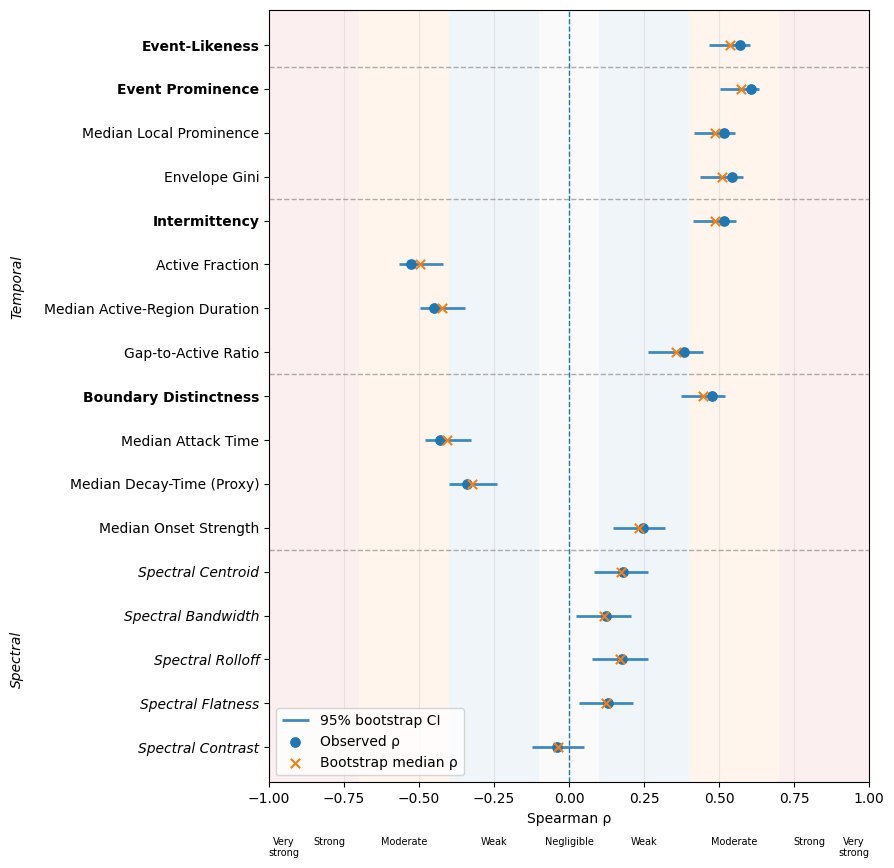

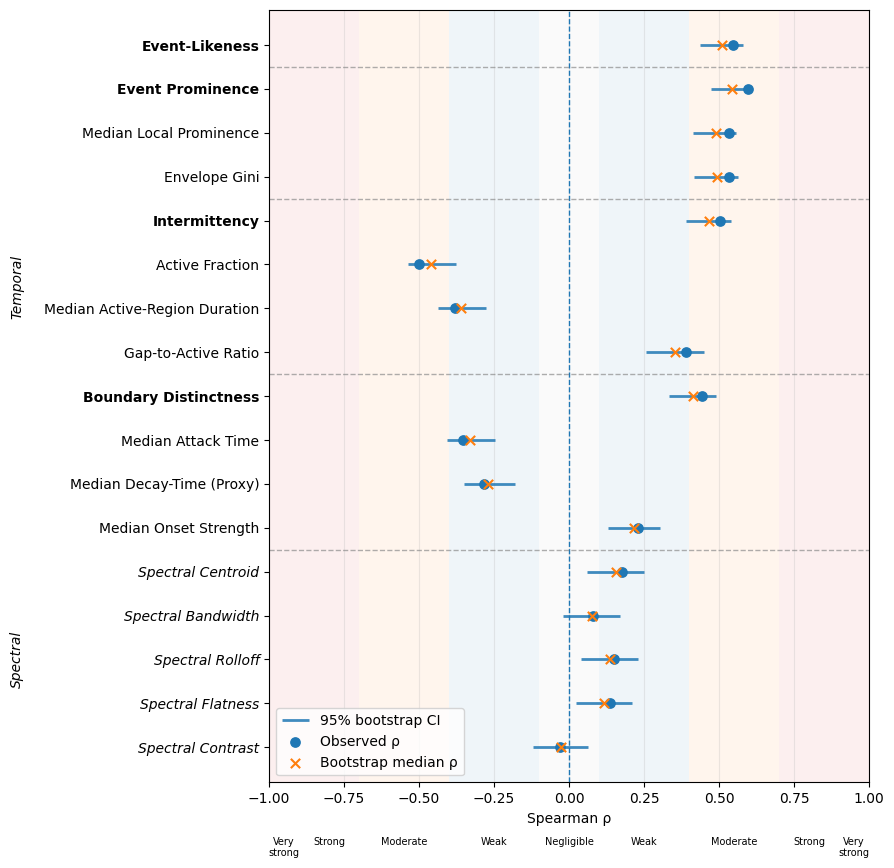

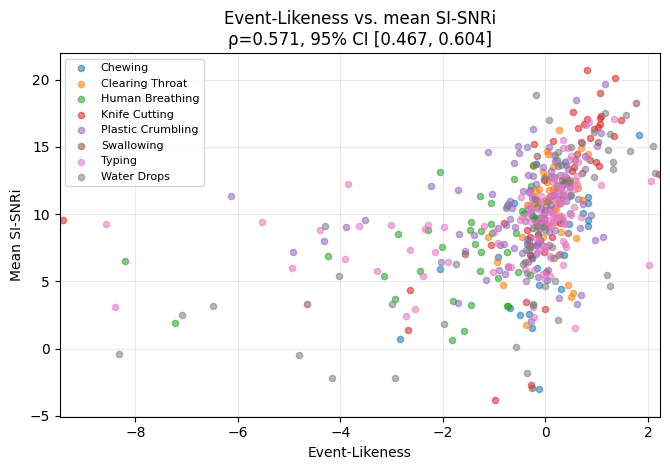

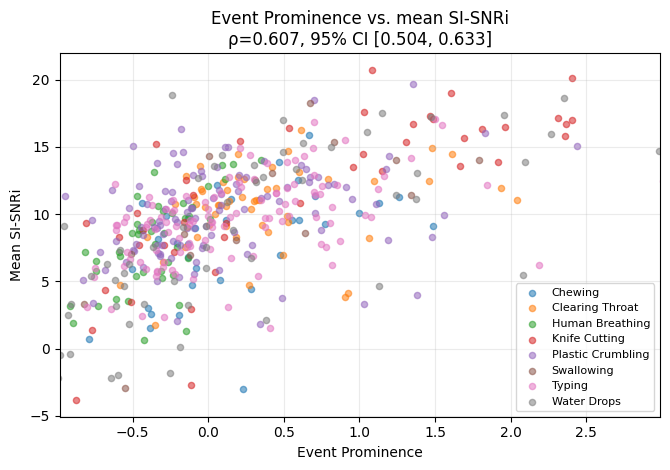

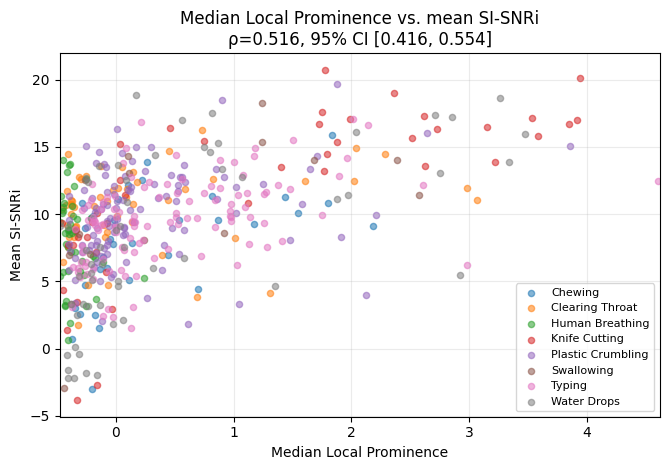

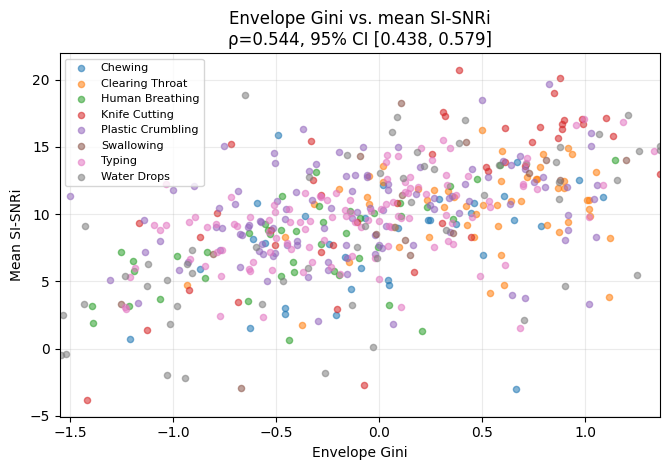

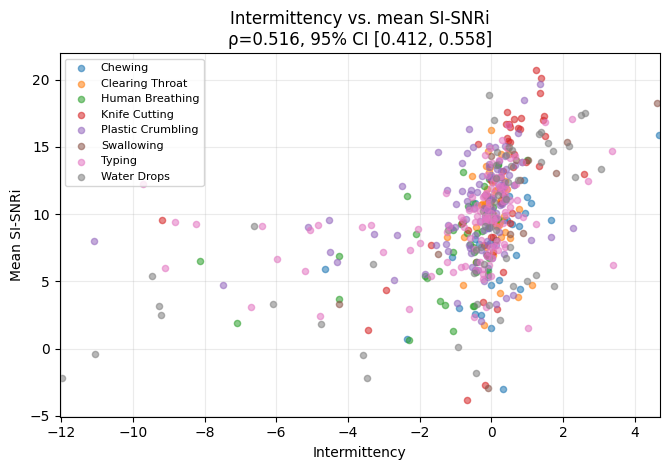

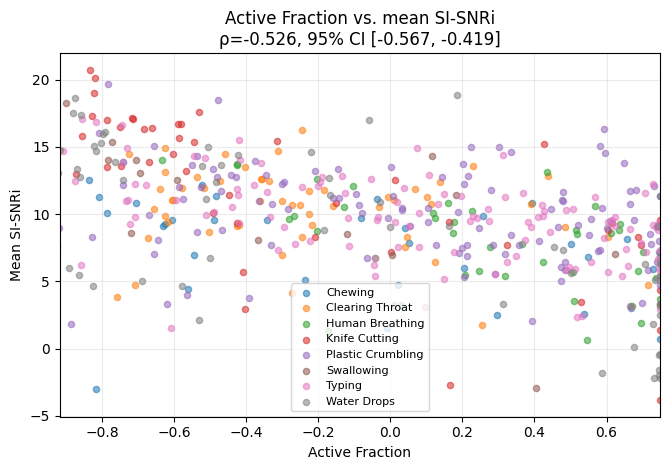

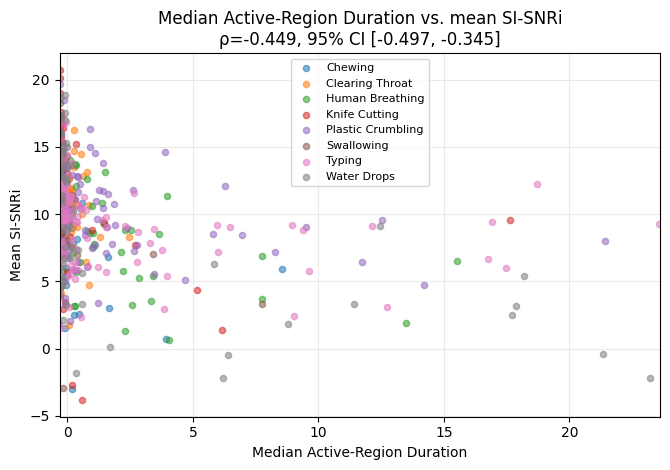

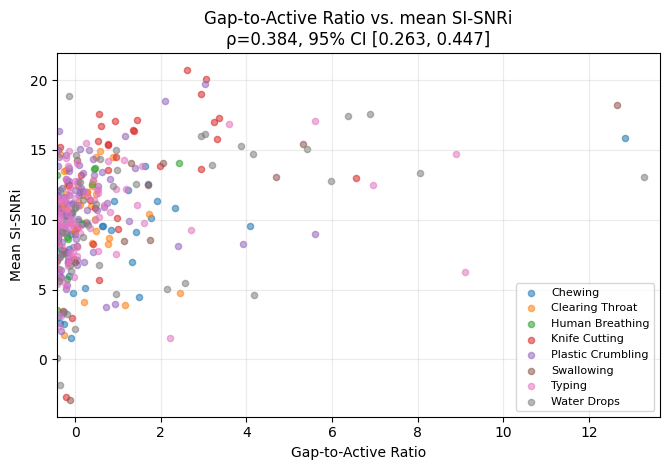

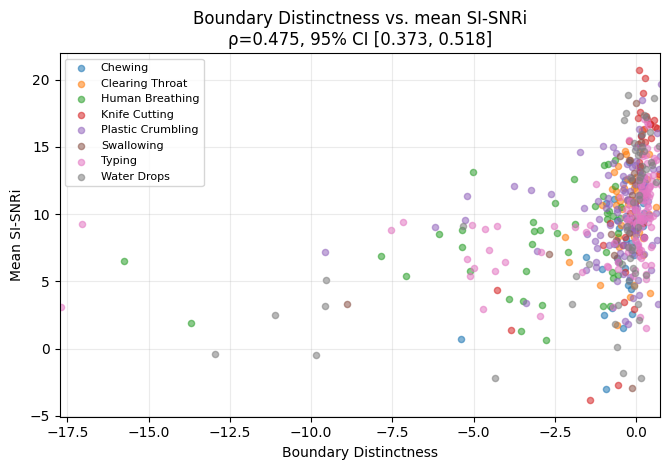

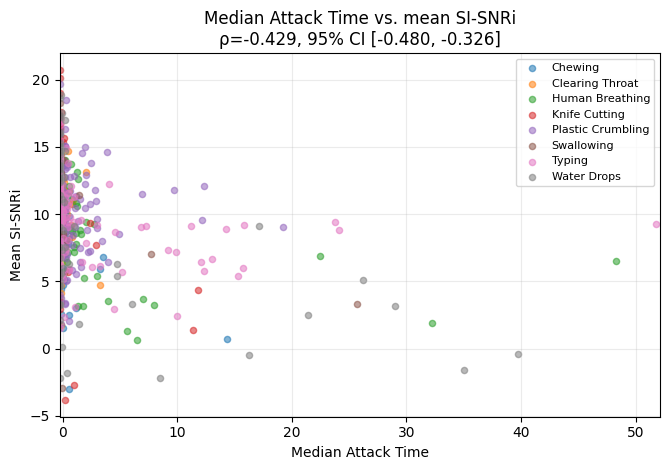

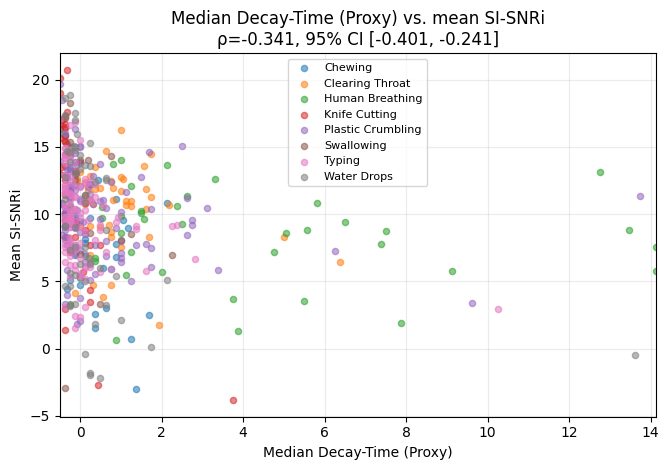

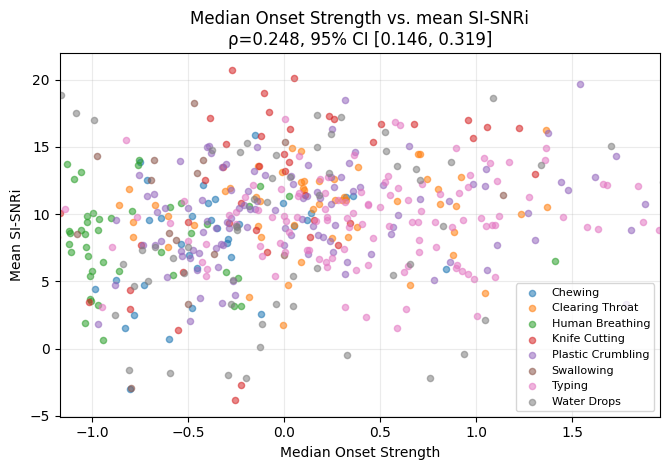

In [35]:

FEATURE_GROUPS = {
    "Temporal": {
        "label_kwargs": {
            "fontstyle": "italic",
            "fontweight": "normal",
        },
        "features": {
            "broad_event_structure_score": {
                "fontweight": "bold",
                # "underline": True,
            },
            # Event Prominance
            "salience_sparsity_score": { "fontweight": "bold", "sep_above": True }, 
            "median_local_prominence_db_z": { "fontweight": "normal" },
            "envelope_gini_z": { "fontweight": "normal" },
            # Intermittency
            "intermittency_score":  { "fontweight": "bold" , "sep_above": True},
            "active_fraction_z": { "fontweight": "normal" },
            "median_active_region_duration_s_z": { "fontweight": "normal" },
             "gap_to_active_ratio_z": { "fontweight": "normal" },
            # Boundary Distinctness
            "boundary_sharpness_score":  { "fontweight": "bold", "sep_above": True },
            "median_attack_time_s_z": { "fontweight": "normal" },
            "median_decay_time_s_z": { "fontweight": "normal" },
            "median_onset_strength_z": { "fontweight": "normal" },
        },
    },
    "Spectral": {
        "label_kwargs": {
            "fontstyle": "italic",
            "fontweight": "normal",
        },
        "features": {
            "spectral_centroid_hz_z": { "fontstyle": "italic", "sep_above": True  },
            "spectral_bandwidth_hz_z": {  "fontstyle": "italic"},
            "spectral_rolloff_hz_z": {  "fontstyle": "italic" },
            "spectral_flatness_z": {  "fontstyle": "italic" },
            "spectral_contrast_z": {  "fontstyle": "italic" },
        }
    }
}


# FEATURE_GROUPS = {
#     "Temporal Scores": {
#         "label_kwargs": {
#             # bold
#             "fontweight": "bold",
#         },
#         "tick_kwargs": {
#             "fontweight": "bold",
#         },
#         "features": [
#             "broad_event_structure_score",
#         "intermittency_score",
#         "boundary_sharpness_score",
#         "salience_sparsity_score",
        
#     ]},
#     "Temporal Features": {
#         "label_kwargs": {
#             "fontstyle": "italic",
#             "fontweight": "normal",
#         },
#         "tick_kwargs": {
#             "fontstyle": "italic",
#         },
#         "features": [
#             "envelope_gini_z",
#             "median_local_prominence_db_z",
#             "active_fraction_z",
#             "median_active_region_duration_s_z",
#             "gap_to_active_ratio_z",
#             "median_attack_time_s_z",
#             "median_decay_time_s_z",
#             "median_onset_strength_z",
#         ]
#     },
#     "Spectral Features": {
#         "label_kwargs": {
#             "fontstyle": "italic",
#             "fontweight": "normal",
#         },
#         "tick_kwargs": {
#             "fontstyle": "italic",

#         },
#         "features": [
#             "spectral_centroid_hz_z",
#             "spectral_bandwidth_hz_z",
#             "spectral_rolloff_hz_z",
#             "spectral_flatness_z",
#             "spectral_contrast_z",
#         ]
#     }
# }

plots_dir = get_data_dir() / "report_figs"

plot_correlation_forest(
    source_level_summary,
    features=FEATURE_GROUPS,
    save_to=plots_dir / "source_correlations_all_main_features.pdf",
)

plot_correlation_forest(
    category_centered_summary,
    features=FEATURE_GROUPS,
    save_to=plots_dir / "category_centered_correlations_all_main_features.pdf",
)

for feature in FEATURE_GROUPS["Temporal"]["features"]:
    plot_feature_scatter(
        source_table=feature_boot.source_table,
        summary=source_level_summary,
        feature=feature,
        level="source_id",
    )